# 02 - Feature Engineering - OULAD

**Objetivo específico 2:** Derivar variables a partir de la interacción estudiantil en
el LMS, tales como frecuencia de acceso, número de clics, regularidad de participación,
variación temporal de la actividad y tiempo transcurrido desde la última interacción.

Proyecto: Modelo predictivo del abandono estudiantil en entornos LMS (OULAD)

**Insumos de `01_carga_exploracion.ipynb`:**
- Variable objetivo: 30.90% de abandono (10,072 / 32,593), desbalance moderado.
- Llaves de union verificadas sin inconsistencias.
- 2,711 estudiantes en `studentInfo` sin ningun registro en `studentVle`.
- 6.47% de interacciones con `date < 0` (antes del inicio formal del curso).
- 5.34% de nulos en `assessments.date`, correspondientes a evaluaciones tipo *Exam*.

Este notebook resuelve las decisiones metodologicas pendientes dejadas en el notebook 01
y construye el dataset analitico consolidado (Resultado esperado 1 del anteproyecto).


In [35]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## A2.1 - Integracion de tablas

Se cargan las tablas necesarias para relacionar informacion del estudiante, curso,
evaluacion e interaccion con el VLE.

In [36]:
studentInfo = pd.read_csv(RAW_DIR / 'studentInfo.csv')
studentRegistration = pd.read_csv(RAW_DIR / 'studentRegistration.csv')
studentAssessment = pd.read_csv(RAW_DIR / 'studentAssessment.csv')
assessments = pd.read_csv(RAW_DIR / 'assessments.csv')
studentVle = pd.read_csv(RAW_DIR / 'studentVle.csv')
vle = pd.read_csv(RAW_DIR / 'vle.csv')
courses = pd.read_csv(RAW_DIR / 'courses.csv')

print(f"studentInfo:         {studentInfo.shape}")
print(f"studentRegistration: {studentRegistration.shape}")
print(f"studentAssessment:   {studentAssessment.shape}")
print(f"assessments:         {assessments.shape}")
print(f"studentVle:          {studentVle.shape}")
print(f"vle:                 {vle.shape}")
print(f"courses:             {courses.shape}")

studentInfo:         (32593, 12)
studentRegistration: (32593, 5)
studentAssessment:   (173912, 5)
assessments:         (206, 6)
studentVle:          (10655280, 6)
vle:                 (6364, 6)
courses:             (22, 3)


In [37]:
# Base de trabajo: una fila por estudiante x modulo x presentacion
base = studentRegistration.merge(
    studentInfo,
    on=['id_student', 'code_module', 'code_presentation'],
    how='inner'
)

base['abandono'] = base['date_unregistration'].notnull().astype(int)

print(f"Shape de la base consolidada: {base.shape}")
assert len(base) == len(studentRegistration), "Se perdieron filas en el merge de base"
base.head()

Shape de la base consolidada: (32593, 15)


,code_module,code_presentation,id_student,date_registration,date_unregistration,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,abandono
0,AAA,2013J,11391,-159.0,NaN,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0
1,AAA,2013J,28400,-53.0,NaN,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0
2,AAA,2013J,30268,-92.0,12.0,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1
3,AAA,2013J,31604,-52.0,NaN,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,0
4,AAA,2013J,32885,-176.0,NaN,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,0


## A2.2 - Definicion de ventanas temporales

**Decision metodologica (deriva del hallazgo 5.2 del notebook 01):** se define la
ventana temprana como los primeros **28 dias (4 semanas)** posteriores al inicio formal
del curso (`date` entre 0 y 27, inclusive), en linea con el uso habitual de ventanas de
4 semanas en la literatura sobre prediccion temprana de abandono en OULAD
[da Silva et al., 2026].

**Tratamiento de `date < 0`:** las interacciones previas al inicio formal del curso
(6.47% del total, ver notebook 01) **no se descartan**, pero se excluyen de la ventana
temprana propiamente dicha y se capturan por separado como una variable binaria de
*interaccion anticipada* (`interaccion_pre_curso`), bajo la hipotesis de que dicha
anticipacion puede constituir una senal de compromiso, no de riesgo.


In [38]:
VENTANA_TEMPRANA_DIAS = 28  # primeras 4 semanas

# Interaccion previa al inicio formal del curso (date < 0)
interaccion_pre_curso = (
    studentVle[studentVle['date'] < 0]
    .groupby(['id_student', 'code_module', 'code_presentation'])
    .size()
    .reset_index(name='n_interacciones_pre_curso')
)
interaccion_pre_curso['interaccion_pre_curso'] = 1

print(f"Estudiantes con interaccion pre-curso: {len(interaccion_pre_curso)}")
interaccion_pre_curso.head()

Estudiantes con interaccion pre-curso: 23809


,id_student,code_module,code_presentation,n_interacciones_pre_curso,interaccion_pre_curso
0,6516,AAA,2014J,53,1
1,8462,DDD,2013J,22,1
2,11391,AAA,2013J,11,1
3,23629,BBB,2013B,3,1
4,23698,CCC,2014J,56,1


In [39]:
# Filtrar studentVle a la ventana temprana (0 a 27 dias inclusive)
svle_temprana = studentVle[
    (studentVle['date'] >= 0) & (studentVle['date'] < VENTANA_TEMPRANA_DIAS)
].copy()

print(f"Registros studentVle totales: {len(studentVle)}")
print(f"Registros en ventana temprana (0-27 dias): {len(svle_temprana)} "
      f"({len(svle_temprana) / len(studentVle) * 100:.2f}%)")

Registros studentVle totales: 10655280
Registros en ventana temprana (0-27 dias): 2112323 (19.82%)


## A2.3 - Variables agregadas de interaccion

Se construyen, sobre la ventana temprana, las variables: numero total de clics,
cantidad de dias activos, frecuencia de acceso y promedio de actividad por periodo.

In [40]:
agg_interaccion = svle_temprana.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    total_clics=('sum_click', 'sum'),
    dias_activos=('date', 'nunique'),
    n_interacciones=('sum_click', 'count'),
).reset_index()

agg_interaccion['promedio_clics_por_dia_activo'] = (
    agg_interaccion['total_clics'] / agg_interaccion['dias_activos']
)
agg_interaccion['frecuencia_acceso'] = (
    agg_interaccion['dias_activos'] / VENTANA_TEMPRANA_DIAS
)

print(f"Estudiantes con actividad en ventana temprana: {len(agg_interaccion)}")
agg_interaccion.drop(columns='id_student').describe()

Estudiantes con actividad en ventana temprana: 27886


,total_clics,dias_activos,n_interacciones,promedio_clics_por_dia_activo,frecuencia_acceso
count,27886.000000,27886.000000,27886.000000,27886.000000,27886.000000
mean,279.043355,10.819874,75.748512,22.394887,0.386424
std,327.939914,6.991786,65.459343,15.815491,0.249707
min,1.000000,1.000000,1.000000,1.000000,0.035714
25%,72.000000,5.000000,27.000000,11.666667,0.178571
50%,179.000000,10.000000,58.000000,18.928571,0.357143
75%,370.000000,16.000000,106.000000,29.142857,0.571429
max,6084.000000,28.000000,589.000000,274.666667,1.000000


## A2.4 - Variables de continuidad e inactividad

Se construyen variables de regularidad de participacion, semanas sin actividad y
tiempo transcurrido desde la ultima interaccion (dentro de la ventana temprana).

In [41]:
# Ultimo dia de interaccion dentro de la ventana temprana, por estudiante
ultima_interaccion = svle_temprana.groupby(
    ['id_student', 'code_module', 'code_presentation']
)['date'].max().reset_index(name='ultimo_dia_interaccion_temprana')

ultima_interaccion['dias_desde_ultima_interaccion'] = (
    (VENTANA_TEMPRANA_DIAS - 1) - ultima_interaccion['ultimo_dia_interaccion_temprana']
)

# Regularidad: desviacion estandar de clics diarios (mayor = mas irregular)
clics_por_dia = svle_temprana.groupby(
    ['id_student', 'code_module', 'code_presentation', 'date']
)['sum_click'].sum().reset_index()

regularidad = clics_por_dia.groupby(
    ['id_student', 'code_module', 'code_presentation']
)['sum_click'].agg(std_clics_diarios='std', media_clics_diarios='mean').reset_index()

regularidad['coef_variacion_clics'] = (
    regularidad['std_clics_diarios'] / regularidad['media_clics_diarios']
).replace([np.inf, -np.inf], np.nan)

print(f"Ultima interaccion calculada para: {len(ultima_interaccion)} estudiantes")
print(f"Regularidad calculada para: {len(regularidad)} estudiantes")
regularidad.drop(columns='id_student').describe()

Ultima interaccion calculada para: 27886 estudiantes
Regularidad calculada para: 27886 estudiantes


,std_clics_diarios,media_clics_diarios,coef_variacion_clics
count,26443.000000,27886.000000,26443.000000
mean,22.554197,22.394887,0.959070
std,18.684581,15.815491,0.340815
min,0.000000,1.000000,0.000000
25%,10.342066,11.666667,0.739802
50%,18.374553,18.928571,0.922093
75%,30.247198,29.142857,1.150858
max,959.704918,274.666667,3.494071


In [42]:
# Semanas sin actividad dentro de la ventana temprana (de 4 semanas)
clics_por_dia['semana'] = clics_por_dia['date'] // 7

semanas_activas = clics_por_dia.groupby(
    ['id_student', 'code_module', 'code_presentation']
)['semana'].nunique().reset_index(name='semanas_activas')

semanas_activas['semanas_inactivas'] = 4 - semanas_activas['semanas_activas']

semanas_activas.head()

,id_student,code_module,code_presentation,semanas_activas,semanas_inactivas
0,6516,AAA,2014J,4,0
1,8462,DDD,2013J,4,0
2,8462,DDD,2014J,1,3
3,11391,AAA,2013J,3,1
4,23629,BBB,2013B,4,0


## A2.5 - Variables de desempeno academico inicial

Se construyen a partir de las entregas de evaluaciones dentro de la ventana temprana.

**Tratamiento del hallazgo 5.4 del notebook 01 (nulos en `assessments.date`):** las
evaluaciones tipo *Exam* sin fecha definida se excluyen naturalmente de este calculo,
dado que corresponden a evaluaciones finales que no ocurren dentro de la ventana
temprana de 4 semanas. No se requiere imputacion; se documenta la exclusion como
intencional.

In [43]:
# Unir evaluaciones entregadas con sus metadatos (tipo, fecha limite, peso)
sa_con_meta = studentAssessment.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation', 'assessment_type', 'date']],
    on='id_assessment',
    how='left',
    suffixes=('', '_limite')
)

# Ventana temprana: evaluaciones con fecha de entrega dentro de los primeros 28 dias
sa_temprana = sa_con_meta[
    (sa_con_meta['date_submitted'] >= 0) & (sa_con_meta['date_submitted'] < VENTANA_TEMPRANA_DIAS)
].copy()

desempeno_temprano = sa_temprana.groupby(
    ['id_student', 'code_module', 'code_presentation']
).agg(
    n_evaluaciones_entregadas=('id_assessment', 'count'),
    score_promedio_temprano=('score', 'mean'),
    score_min_temprano=('score', 'min'),
).reset_index()

print(f"Estudiantes con al menos una entrega en ventana temprana: {len(desempeno_temprano)}")
desempeno_temprano.drop(columns='id_student').describe()

Estudiantes con al menos una entrega en ventana temprana: 20114


,n_evaluaciones_entregadas,score_promedio_temprano,score_min_temprano
count,20114.00000,20102.000000,20102.000000
mean,1.15795,72.777282,71.976321
std,0.42408,21.997780,22.033876
min,1.00000,0.000000,0.000000
25%,1.00000,65.000000,64.000000
50%,1.00000,78.000000,76.000000
75%,1.00000,88.000000,86.000000
max,4.00000,100.000000,100.000000


## A2.6 - Variables de tendencia temporal

Se compara la actividad de la primera quincena (dias 0-13) contra la segunda quincena
(dias 14-27) de la ventana temprana, para capturar disminucion o aumento progresivo de
la participacion.

In [44]:
clics_por_dia['quincena'] = np.where(clics_por_dia['date'] < 14, 1, 2)

clics_por_quincena = clics_por_dia.groupby(
    ['id_student', 'code_module', 'code_presentation', 'quincena']
)['sum_click'].sum().unstack(fill_value=0)

clics_por_quincena.columns = ['clics_quincena_1', 'clics_quincena_2']
clics_por_quincena = clics_por_quincena.reset_index()

# Variacion relativa: positivo = aumento de actividad, negativo = disminucion
clics_por_quincena['variacion_actividad'] = (
    (clics_por_quincena['clics_quincena_2'] - clics_por_quincena['clics_quincena_1']) /
    clics_por_quincena['clics_quincena_1'].replace(0, np.nan)
)

clics_por_quincena.drop(columns='id_student').describe()

,clics_quincena_1,clics_quincena_2,variacion_actividad
count,27886.000000,27886.000000,26425.000000
mean,136.653697,142.389658,2.016184
std,181.521460,178.139555,12.576265
min,0.000000,0.000000,-1.000000
25%,25.000000,26.000000,-0.595745
50%,78.000000,86.000000,-0.070707
75%,181.000000,193.000000,0.934783
max,4733.000000,3307.000000,636.000000


## Analisis complementario - Cruce entre inactividad total y abandono formal

Se retoma el hallazgo 5.3 del notebook 01: 2,711 estudiantes en `studentInfo` sin
ningun registro en `studentVle`. Se contrasta esta poblacion contra la variable de
abandono formal (`date_unregistration`) para establecer si dicha inactividad total
coincide con un retiro ya registrado o si representa un patron de desvinculacion no
capturado por el criterio formal (actividad A3.1 de la metodologia).

In [45]:
ids_con_interaccion = set(
    studentVle[['id_student', 'code_module', 'code_presentation']]
    .drop_duplicates()
    .apply(tuple, axis=1)
)
ids_todos_registro = set(
    base[['id_student', 'code_module', 'code_presentation']]
    .apply(tuple, axis=1)
)
ids_sin_interaccion_registro = ids_todos_registro - ids_con_interaccion

print(f"Total registros (estudiante x modulo x presentacion): {len(ids_todos_registro)}")
print(f"Registros sin ninguna interaccion en VLE: {len(ids_sin_interaccion_registro)}")

base['clave_registro'] = list(zip(base['id_student'], base['code_module'], base['code_presentation']))
sin_interaccion_df = base[base['clave_registro'].isin(ids_sin_interaccion_registro)].copy()

n_sin_interaccion = len(sin_interaccion_df)
n_sin_interaccion_y_abandono = sin_interaccion_df['abandono'].sum()
pct_coincide = n_sin_interaccion_y_abandono / n_sin_interaccion * 100

print(f"\nRegistros (estudiante x modulo x presentacion) sin interaccion: {n_sin_interaccion}")
print(f"De estos, con abandono formal registrado: {n_sin_interaccion_y_abandono} ({pct_coincide:.2f}%)")
print(f"Sin interaccion y SIN abandono formal registrado: "
      f"{n_sin_interaccion - n_sin_interaccion_y_abandono} "
      f"({100 - pct_coincide:.2f}%)")

Total registros (estudiante x modulo x presentacion): 32593
Registros sin ninguna interaccion en VLE: 3365

Registros (estudiante x modulo x presentacion) sin interaccion: 3365
De estos, con abandono formal registrado: 2970 (88.26%)
Sin interaccion y SIN abandono formal registrado: 395 (11.74%)


**Nota metodologica:** este calculo opera sobre la unidad de analisis correcta
establecida en el hallazgo 5.1 del notebook 01 (estudiante x modulo x presentacion),
y no sobre el estudiante como individuo. Un estudiante inscrito en mas de un curso
puede tener actividad en uno y ninguna actividad en otro; el calculo por estudiante
unico subestimaria el numero real de inscripciones sin interaccion.

<Axes: title={'center': 'Abandono formal entre estudiantes sin ninguna interaccion en VLE'}, xlabel='abandono'>

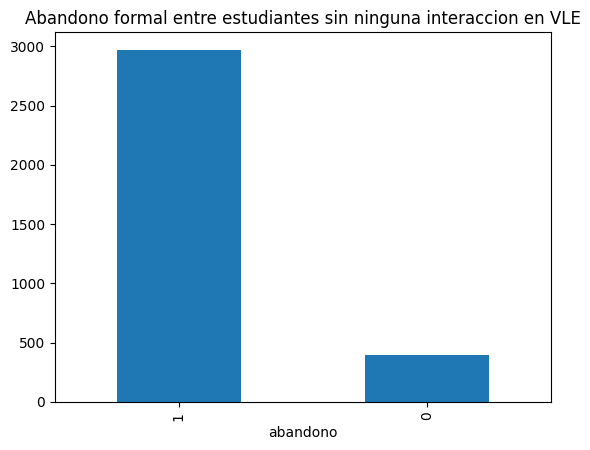

In [46]:
sin_interaccion_df['abandono'].value_counts().plot(
    kind='bar',
    title='Abandono formal entre estudiantes sin ninguna interaccion en VLE'
)

**Interpretacion pendiente de completar con los resultados reales:**

- Si el porcentaje de coincidencia con abandono formal es **alto** (cercano al 100%),
  la inactividad total ya esta mayoritariamente capturada por
  `date_unregistration`, y no aporta una senal adicional relevante como variable
  independiente.
- Si el porcentaje de coincidencia es **bajo**, existe un grupo de estudiantes que
  permanecen formalmente matriculados (sin retiro registrado) pero completamente
  inactivos — este grupo constituye el caso mas claro de **abandono implicito** y
  justifica la construccion de una variable adicional
  `abandono_implicito_total` = 1 si `id_student` esta en `ids_sin_interaccion` y
  `abandono` = 0.

Esta variable, de justificarse, se documentara como un indicador complementario
exploratorio (no como reemplazo de la variable objetivo principal definida en A3.1),
en linea con lo planteado en el alcance del anteproyecto.

In [47]:
# Construccion de la variable exploratoria de abandono implicito
# (usa la clave compuesta estudiante x modulo x presentacion, no el estudiante unico)
base['sin_interaccion_vle'] = base['clave_registro'].isin(ids_sin_interaccion_registro).astype(int)
base['abandono_implicito_total'] = (
    (base['sin_interaccion_vle'] == 1) & (base['abandono'] == 0)
).astype(int)
base = base.drop(columns='clave_registro')

print(f"Casos de abandono implicito total (inactivo y sin retiro formal): "
      f"{base['abandono_implicito_total'].sum()}")

Casos de abandono implicito total (inactivo y sin retiro formal): 395


## Validacion del hallazgo - cruce con `final_result`

Para fortalecer la interpretacion del abandono implicito, se contrasta la poblacion de
inscripciones sin interaccion y sin retiro formal contra el resultado final oficial
registrado en `studentInfo['final_result']` (categorias: `Withdrawn`, `Fail`, `Pass`,
`Distinction`). Si esta poblacion se concentra en las categorias `Fail` o `Withdrawn`,
se refuerza la hipotesis de que representa un patron real de desvinculacion academica y
no ruido en los datos.

In [48]:
# Filtrar los casos de abandono implicito total
casos_implicito = base[base['abandono_implicito_total'] == 1].copy()

# Cruzar contra final_result (ya incluido en 'base' por el merge con studentInfo en A2.1)
distribucion_final_result = casos_implicito['final_result'].value_counts()
distribucion_final_result_pct = (
    casos_implicito['final_result'].value_counts(normalize=True) * 100
).round(2)

resumen_validacion = pd.DataFrame({
    'n_casos': distribucion_final_result,
    'porcentaje': distribucion_final_result_pct
})

print(f"Distribucion de final_result entre los {len(casos_implicito)} casos de abandono implicito:\n")
print(resumen_validacion)

Distribucion de final_result entre los 395 casos de abandono implicito:

              n_casos  porcentaje
final_result                     
Fail              373       94.43
Withdrawn          19        4.81
Pass                3        0.76


<Axes: title={'center': 'final_result entre casos de abandono implicito (inactivos sin retiro formal)'}, xlabel='final_result'>

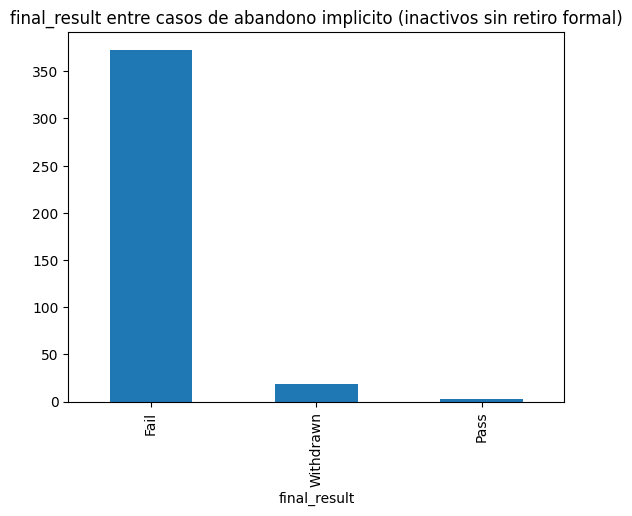

In [49]:
resumen_validacion['n_casos'].plot(
    kind='bar',
    title='final_result entre casos de abandono implicito (inactivos sin retiro formal)'
)

**Interpretacion pendiente de completar con los resultados obtenidos:**

- Si la mayoria de los casos cae en `Fail` o `Withdrawn`, se confirma que
  `abandono_implicito_total` captura un patron real de desvinculacion academica no
  registrado por el criterio formal de retiro - se conserva como variable
  exploratoria complementaria, documentando esta validacion como evidencia de
  respaldo.
- Si una proporcion relevante cae en `Pass` o `Distinction`, esos casos podrian
  corresponder a estudiantes con formas de interaccion no capturadas por
  `studentVle` (por ejemplo, actividad exclusivamente presencial o mediada por otro
  canal), y la variable debe interpretarse con mayor cautela, dejando constancia de
  esta limitacion en la documentacion del dataset analitico final.

## A2.7 - Consolidacion del dataset final

Se integran todas las variables derivadas sobre la base de estudiante x modulo x
presentacion, y se guarda el resultado en formato parquet.

In [50]:
dataset_final = base.merge(
    agg_interaccion, on=['id_student', 'code_module', 'code_presentation'], how='left'
).merge(
    ultima_interaccion, on=['id_student', 'code_module', 'code_presentation'], how='left'
).merge(
    regularidad, on=['id_student', 'code_module', 'code_presentation'], how='left'
).merge(
    semanas_activas, on=['id_student', 'code_module', 'code_presentation'], how='left'
).merge(
    desempeno_temprano, on=['id_student', 'code_module', 'code_presentation'], how='left'
).merge(
    clics_por_quincena, on=['id_student', 'code_module', 'code_presentation'], how='left'
).merge(
    interaccion_pre_curso[['id_student', 'code_module', 'code_presentation', 'interaccion_pre_curso']],
    on=['id_student', 'code_module', 'code_presentation'], how='left'
)

# Estudiantes sin actividad en la ventana temprana => variables de interaccion en 0/NaN por diseno
dataset_final['interaccion_pre_curso'] = dataset_final['interaccion_pre_curso'].fillna(0)
dataset_final['sin_actividad_ventana_temprana'] = dataset_final['dias_activos'].isna().astype(int)

print(f"Shape del dataset final consolidado: {dataset_final.shape}")
print(f"\nColumnas: {list(dataset_final.columns)}")
dataset_final.head()

Shape del dataset final consolidado: (32593, 37)

Columnas: ['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'abandono', 'sin_interaccion_vle', 'abandono_implicito_total', 'total_clics', 'dias_activos', 'n_interacciones', 'promedio_clics_por_dia_activo', 'frecuencia_acceso', 'ultimo_dia_interaccion_temprana', 'dias_desde_ultima_interaccion', 'std_clics_diarios', 'media_clics_diarios', 'coef_variacion_clics', 'semanas_activas', 'semanas_inactivas', 'n_evaluaciones_entregadas', 'score_promedio_temprano', 'score_min_temprano', 'clics_quincena_1', 'clics_quincena_2', 'variacion_actividad', 'interaccion_pre_curso', 'sin_actividad_ventana_temprana']


,code_module,code_presentation,id_student,date_registration,date_unregistration,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,abandono,sin_interaccion_vle,abandono_implicito_total,total_clics,dias_activos,n_interacciones,promedio_clics_por_dia_activo,frecuencia_acceso,ultimo_dia_interaccion_temprana,dias_desde_ultima_interaccion,std_clics_diarios,media_clics_diarios,coef_variacion_clics,semanas_activas,semanas_inactivas,n_evaluaciones_entregadas,score_promedio_temprano,score_min_temprano,clics_quincena_1,clics_quincena_2,variacion_actividad,interaccion_pre_curso,sin_actividad_ventana_temprana
0,AAA,2013J,11391,-159.0,NaN,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,0,0,303.0,7.0,49.0,43.285714,0.250000,18.0,9.0,42.507702,43.285714,0.982026,3.0,1.0,1.0,78.0,78.0,203.0,100.0,-0.507389,1.0,0
1,AAA,2013J,28400,-53.0,NaN,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0,0,0,335.0,11.0,94.0,30.454545,0.392857,24.0,3.0,21.653469,30.454545,0.711009,4.0,0.0,1.0,70.0,70.0,241.0,94.0,-0.609959,1.0,0
2,AAA,2013J,30268,-92.0,12.0,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1,0,0,179.0,6.0,42.0,29.833333,0.214286,12.0,15.0,15.065413,29.833333,0.504986,2.0,2.0,NaN,NaN,NaN,179.0,0.0,-1.000000,1.0,0
3,AAA,2013J,31604,-52.0,NaN,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,0,0,0,309.0,16.0,98.0,19.312500,0.571429,25.0,2.0,17.567845,19.312500,0.909662,4.0,0.0,1.0,72.0,72.0,176.0,133.0,-0.244318,1.0,0
4,AAA,2013J,32885,-176.0,NaN,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,0,0,0,272.0,16.0,85.0,17.000000,0.571429,26.0,1.0,12.011106,17.000000,0.706536,4.0,0.0,1.0,69.0,69.0,177.0,95.0,-0.463277,1.0,0


In [51]:
ruta_salida = PROCESSED_DIR / 'dataset_analitico_oulad.parquet'
dataset_final.to_parquet(ruta_salida, index=False)
print(f"Dataset guardado en: {ruta_salida}")
print(f"Filas: {len(dataset_final)} | Columnas: {dataset_final.shape[1]}")

Dataset guardado en: ..\data\processed\dataset_analitico_oulad.parquet
Filas: 32593 | Columnas: 37


## Resumen de variables derivadas construidas

| Variable | Actividad | Descripcion |
|---|---|---|
| `total_clics` | A2.3 | Suma de clics en ventana temprana (0-27 dias) |
| `dias_activos` | A2.3 | Numero de dias distintos con actividad |
| `frecuencia_acceso` | A2.3 | Proporcion de dias activos sobre el total de la ventana |
| `promedio_clics_por_dia_activo` | A2.3 | Intensidad de uso por dia activo |
| `dias_desde_ultima_interaccion` | A2.4 | Dias transcurridos desde la ultima interaccion hasta el fin de la ventana |
| `std_clics_diarios` / `coef_variacion_clics` | A2.4 | Regularidad de la participacion |
| `semanas_activas` / `semanas_inactivas` | A2.4 | Continuidad semanal dentro de la ventana |
| `n_evaluaciones_entregadas` | A2.5 | Cumplimiento de actividades evaluativas tempranas |
| `score_promedio_temprano` / `score_min_temprano` | A2.5 | Desempeno academico inicial |
| `variacion_actividad` | A2.6 | Cambio de participacion entre quincenas |
| `interaccion_pre_curso` | A2.2 | Actividad registrada antes del inicio formal del curso |
| `sin_interaccion_vle` | Hallazgo 5.3 (notebook 01) | Estudiante sin ningun registro en studentVle |
| `abandono_implicito_total` | Hallazgo 5.3 (notebook 01) | Inactivo total y sin retiro formal registrado (exploratoria) |

## Proximos pasos

- Pasar al notebook `03_modelado_comparacion.ipynb` (Objetivo 3): division
  estratificada, tratamiento de valores faltantes en las variables derivadas
  (estudiantes sin actividad en la ventana temprana), y entrenamiento de los modelos
  candidatos (regresion logistica, Random Forest, XGBoost, LightGBM).
- Documentar en el dataset analitico final la proporcion de valores faltantes
  introducidos por estudiantes sin actividad en la ventana temprana, antes de decidir
  la estrategia de imputacion.
